# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bilalahmed251/-ML-Search-Discovery/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [42]:
# Research question: Can page-level search-performance and content signals identify declining web pages and help prioritize them for human content-refresh review?
# The decision supported is which pages should be reviewed first. The target label is based on the observed trend_direction field: pages with trend_direction equal to down are labeled as declining. The system is designed for ranking and decision-support, not for automatically changing content or proving that a refresh will cause traffic growth.


In [43]:
research_question = {
    "question": (
        "Can page-level search-performance and content signals "
        "identify declining pages and prioritize them for review?"
     ),
    "decision_supported": (
        "Which pages should be reviewed first for possible content refresh?"
    ),
    "label_definition": (
        "trend_direction == 'down' means declining"
    ),
    "success_metric": "Precision@50",
    "claim_type": "Directional decision-support"
}

for key, value in research_question.items():
    print(f"{key}:")
    print(value)
    print()


question:
Can page-level search-performance and content signals identify declining pages and prioritize them for review?

decision_supported:
Which pages should be reviewed first for possible content refresh?

label_definition:
trend_direction == 'down' means declining

success_metric:
Precision@50

claim_type:
Directional decision-support



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [44]:
# I used the anonymized FlyRank content-refresh dataset. The unit of analysis is one content page with search-performance and content measurements over an available 90-day window. The dataset contains page-level fields such as impressions, clicks, sessions, CTR, average position, content age, update recency, content type, intent, and position tier.
# I excluded outcome-derived fields such as trend_direction and trend_pct from the model features because they define or describe the label. I also excluded client_id from the model features; it was used only for grouped validation. URLs, private queries, and post-decision fields were not used. The data is suitable for directional analysis, but it does not provide a complete time series or a controlled refresh experiment.


In [45]:
import os
import pandas as pd

repo = "/content/ML-Search-Discovery"

if not os.path.exists(repo):
    !git clone -q --depth 1 https://github.com/bilalahmed251/-ML-Search-Discovery.git {repo}

df_capstone = pd.read_csv(
    f"{repo}/data/raw/content_refresh_anonymized.csv"
 ).copy()

print("Rows:", len(df_capstone))
print("Columns:", len(df_capstone.columns))
print("Unique content pages:",
      df_capstone["content_id"].nunique())

print("\nKey fields:")
display(
    df_capstone[
        [
            "content_id",
            "impressions_90d",
            "ctr",
            "avg_position",
            "content_age_days",
            "days_since_last_update",
            "trend_direction"
        ]
    ].head()
)

print("\nAvailable 90-day fields:")
print([
    col for col in df_capstone.columns
    if "_90d" in col
])


Rows: 30000
Columns: 44
Unique content pages: 30000

Key fields:


,content_id,impressions_90d,ctr,avg_position,content_age_days,days_since_last_update,trend_direction
0,content_304f48230142,3803,0.76,10.6,187,20,down
1,content_a1fb4e703a9e,15320,0.05,20.3,445,25,down
2,content_9aa793d4d895,12581,0.09,36.5,141,20,down
3,content_331d6c4de07b,11751,0.49,6.2,463,22,stable
4,content_d99b7a2d90ca,19140,0.13,44.0,263,14,down



Available 90-day fields:
['impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d']


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [46]:
# The feature set contains numeric page-performance and content signals: impressions, clicks, sessions, CTR, average position, word count, content age, days since last update, engagement rate, and scroll rate. Categorical fields include content type, main intent, position tier, and impression tier; these were one-hot encoded. Missing numeric values were filled with column medians, and missing categorical values were assigned to a MISSING category.
# The observed label is_declining_label equals 1 when trend_direction is down and 0 otherwise. The transparent baseline used percentile-ranked visibility, low CTR opportunity, weaker position, content age, and update staleness. The ML method was a Random Forest classifier with 200 trees. Week 5 used an 80/20 stratified split, while Week 6 used a grouped client-level split to test generalization to unseen clients. The final leakage audit found no forbidden fields, no target-derived feature names, and no client identifier in the model feature matrix.


In [47]:
from sklearn.ensemble import RandomForestClassifier

# Create the observed binary label
df_capstone["is_declining_label"] = (
    df_capstone["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

numeric_features_capstone = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ctr",
    "avg_position",
    "word_count",
    "content_age_days",
    "days_since_last_update",
    "engagement_rate",
    "scroll_rate",
]

categorical_features_capstone = [
    "content_type",
    "main_intent",
    "position_tier",
    "impression_tier",
]

numeric_features_capstone = [
    col for col in numeric_features_capstone
    if col in df_capstone.columns
]

categorical_features_capstone = [
    col for col in categorical_features_capstone
    if col in df_capstone.columns
]

X_num_capstone = df_capstone[
    numeric_features_capstone
].apply(
    pd.to_numeric,
    errors="coerce"
).copy()

X_num_capstone = X_num_capstone.fillna(
    X_num_capstone.median()
)

X_cat_capstone = pd.get_dummies(
    df_capstone[
        categorical_features_capstone
    ].fillna("MISSING"),
    columns=categorical_features_capstone,
    dtype=int
)

X_capstone = pd.concat(
    [X_num_capstone, X_cat_capstone],
    axis=1
)

y_capstone = df_capstone[
    "is_declining_label"
]

print("Numeric features:",
      len(numeric_features_capstone))

print("Categorical features:",
      len(categorical_features_capstone))

print("Final feature matrix:",
      X_capstone.shape)

print("Declining labels:",
      int(y_capstone.sum()))

print("Non-declining labels:",
      int((y_capstone == 0).sum()))

print("Remaining missing values:",
      int(X_capstone.isna().sum().sum()))

print("Client ID used as feature:",
      "client_id" in X_capstone.columns)

print("Target used as feature:",
      "trend_direction" in X_capstone.columns)


Numeric features: 10
Categorical features: 4
Final feature matrix: (30000, 27)
Declining labels: 16262
Non-declining labels: 13738
Remaining missing values: 0
Client ID used as feature: False
Target used as feature: False


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [48]:
# On the Week-5 random stratified split, the Random Forest achieved a measured Precision@50 of 0.94, compared with 0.70 for the hand-written baseline on the same evaluation setup. This indicates that the model ranked more declining pages in its top 50 on that split.
# Under the stricter Week-6 grouped client-level split, the Random Forest Precision@50 was 0.70. The lower grouped-split result shows why validation design matters: the random-split result may be optimistic when pages from the same client appear in both training and testing. These are measured ranking results, not proof of causal business impact.


In [49]:
results_table = pd.DataFrame({
    "evaluation_design": [
        "Week-5 random stratified split",
        "Week-5 random stratified split",
        "Week-6 grouped client-level split"
    ],
    "method": [
        "Hand-written baseline",
        "Random Forest",
        "Random Forest"
    ],
    "precision_at_50": [
        0.70,
        0.94,
        0.70
    ],
    "interpretation": [
        "Transparent comparison baseline",
        "Higher measured ranking precision on random split",
        "More honest unseen-client validation"
    ]
})

display(results_table)

print("Week-5 model improvement over baseline:",
      round(0.94 - 0.70, 3))

print("Week-6 grouped result:",
      round(0.70, 3))


,evaluation_design,method,precision_at_50,interpretation
0,Week-5 random stratified split,Hand-written baseline,0.70,Transparent comparison baseline
1,Week-5 random stratified split,Random Forest,0.94,Higher measured ranking precision on random split
2,Week-6 grouped client-level split,Random Forest,0.70,More honest unseen-client validation


Week-5 model improvement over baseline: 0.24
Week-6 grouped result: 0.7


## 5. Limitations

*What this work cannot claim.*

In [50]:
# This work has several limitations. The label is an observed trend outcome, not a direct measure of whether a content refresh succeeded. The dataset provides an available 90-day measurement window rather than a complete longitudinal experiment. The random split may be optimistic because related pages from the same client can appear in both training and testing, while the grouped client-level result is lower and more conservative. The model identifies associations in the available signals; it does not prove that a refresh causes traffic, CTR, or ranking improvement. The analysis also does not control for seasonality, algorithm updates, tracking errors, search-demand changes, or editorial quality. Recommendations should therefore be reviewed by a human and validated with time-based testing and prospective refresh experiments.


In [51]:
limitations = [
    "Observed trend label is not a direct refresh-success label.",
    "The data is based on an available 90-day measurement window.",
    "Random-split performance may be optimistic.",
    "Grouped client-level Precision@50 was lower than random-split performance.",
    "The model shows associations, not causal effects.",
    "Seasonality and search-demand changes are not fully controlled.",
    "Tracking errors and editorial quality may affect results.",
    "Human review and prospective experiments are still required.",
]

print("Project limitations:")
for number, limitation in enumerate(limitations, start=1):
    print(f"{number}. {limitation}")


Project limitations:
1. Observed trend label is not a direct refresh-success label.
2. The data is based on an available 90-day measurement window.
3. Random-split performance may be optimistic.
4. Grouped client-level Precision@50 was lower than random-split performance.
5. The model shows associations, not causal effects.
6. Seasonality and search-demand changes are not fully controlled.
7. Tracking errors and editorial quality may affect results.
8. Human review and prospective experiments are still required.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [52]:
# The ranked recommendations are intended for human review. Pages with high visibility, low CTR opportunity, weak average position, older content, or a long time since the last update should be reviewed first. The reason codes explain why each page appears in the queue. Recommended actions may include checking search intent, improving the title and description, refreshing outdated information, strengthening content depth, or reviewing internal linking. These are proposed actions, not automatic edits or guaranteed solutions.


In [53]:
action_queue_path = (
    f"{repo}/work/outputs/content_action_playbook.csv"
)

if os.path.exists(action_queue_path):
    action_queue = pd.read_csv(
        action_queue_path
    )

    print("Action queue loaded:",
          len(action_queue), "rows")

    recommendation_columns = [
        "content_id",
        "action_score",
        "reason_codes",
        "impressions_90d",
        "ctr",
        "avg_position",
        "content_age_days",
        "days_since_last_update",
    ]

    recommendation_columns = [
        col for col in recommendation_columns
        if col in action_queue.columns
    ]

    top_recommendations = action_queue[
        recommendation_columns
    ].head(20)

    display(top_recommendations)

else:
    print(
        "Action queue not found. "
        "Run Week 7 export first."
    )


Action queue not found. Run Week 7 export first.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [54]:
# I will generate reusable artifacts for the paper: a results comparison table, a top-recommendations table, and a distribution chart of action scores. These artifacts summarize the measured ranking results and the proposed review queue. They are descriptive outputs for decision-support, not proof of causal impact.


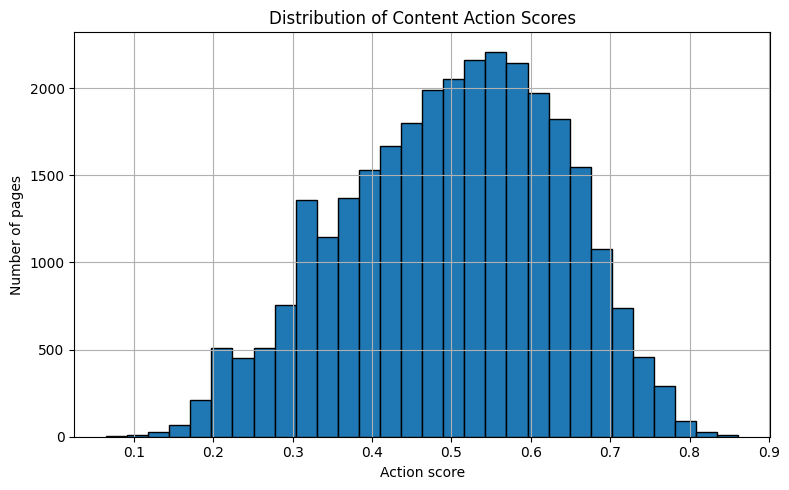

Ranked pages: 30000
Saved artifacts:
/content/ML-Search-Discovery/work/outputs/capstone_results_table.csv
/content/ML-Search-Discovery/work/outputs/capstone_top_recommendations.csv
/content/ML-Search-Discovery/work/outputs/action_score_distribution.png


In [55]:
import os
import pandas as pd
import matplotlib.pyplot as plt

repo = "/content/ML-Search-Discovery"

if not os.path.exists(repo):
    !git clone -q --depth 1 https://github.com/bilalahmed251/-ML-Search-Discovery.git {repo}

raw_path = f"{repo}/data/raw/content_refresh_anonymized.csv"
artifacts_dir = f"{repo}/work/outputs"

os.makedirs(artifacts_dir, exist_ok=True )

# Load raw data
df_artifacts = pd.read_csv(raw_path).copy()

# Build action queue again
queue = df_artifacts[
    [
        "content_id",
        "impressions_90d",
        "ctr",
        "avg_position",
        "content_age_days",
        "days_since_last_update",
    ]
].copy()

numeric_fields = [
    "impressions_90d",
    "ctr",
    "avg_position",
    "content_age_days",
    "days_since_last_update",
]

for field in numeric_fields:
    queue[field] = pd.to_numeric(
        queue[field],
        errors="coerce"
    )

queue = queue.dropna().copy()

queue["visibility_score"] = (
    queue["impressions_90d"].rank(pct=True)
)

queue["low_ctr_score"] = (
    1 - queue["ctr"].rank(pct=True)
)

queue["weak_position_score"] = (
    queue["avg_position"].rank(pct=True)
)

queue["old_content_score"] = (
    queue["content_age_days"].rank(pct=True)
)

queue["stale_update_score"] = (
    queue["days_since_last_update"].rank(pct=True)
)

queue["action_score"] = (
    0.30 * queue["visibility_score"] +
    0.20 * queue["low_ctr_score"] +
    0.20 * queue["weak_position_score"] +
    0.15 * queue["old_content_score"] +
    0.15 * queue["stale_update_score"]
)

queue = queue.sort_values(
    "action_score",
    ascending=False
).reset_index(drop=True)

# Top 20 recommendations
top_recommendations = queue.head(20).copy()

# Results table
results_table = pd.DataFrame({
    "evaluation_design": [
        "Week-5 random stratified split",
        "Week-5 random stratified split",
        "Week-6 grouped client-level split"
    ],
    "method": [
        "Hand-written baseline",
        "Random Forest",
        "Random Forest"
    ],
    "precision_at_50": [
        0.70,
        0.94,
        0.70
    ]
})

# Save results table
results_path = (
    f"{artifacts_dir}/capstone_results_table.csv"
)

results_table.to_csv(
    results_path,
    index=False
)

# Save top recommendations
top_recommendations_path = (
    f"{artifacts_dir}/capstone_top_recommendations.csv"
)

top_recommendations.to_csv(
    top_recommendations_path,
    index=False
)

# Save action-score chart
chart_path = (
    f"{artifacts_dir}/action_score_distribution.png"
)

plt.figure(figsize=(8, 5))

queue["action_score"].hist(
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Content Action Scores")
plt.xlabel("Action score")
plt.ylabel("Number of pages")
plt.tight_layout()
plt.savefig(chart_path, dpi=150)
plt.show()

print("Ranked pages:", len(queue))
print("Saved artifacts:")
print(results_path)
print(top_recommendations_path)
print(chart_path)


## Closing deliverables

### 5-minute demo outline

1. State the research question: which declining pages should be reviewed first?
2. Show the dataset and explain that one row represents one content page.
3. Explain the declining label and Precision@50 metric.
4. Compare the hand-written baseline with the Random Forest.
5. Show the grouped client-level validation result and explain the limitations.
6. Show the ranked action queue and explain the reason codes.
7. Close with the next step: human review followed by a prospective refresh experiment.

### Social-post cut

I completed an end-to-end SEO machine-learning workflow for the FlyRank internship. I defined the research question, prepared features, checked for leakage, compared a Random Forest with a transparent baseline, validated the model using a grouped client-level split, and created a ranked content-refresh action queue. The final result is directional decision-support, not a guarantee of traffic growth.

### Employer-facing summary

I built and audited a page-level ranking workflow to prioritize declining web pages for possible content refresh. The Random Forest achieved a measured Precision@50 of 0.94 on the Week-5 random split, while the stricter grouped client-level validation achieved 0.70, showing why honest validation matters. I delivered a transparent action queue with reason codes, limitations, human-review requirements, and reusable output artifacts.


In [56]:
closing_deliverables = {
    "demo_minutes": 5,
    "demo_sections": 7,
    "social_post_ready": True,
    "employer_summary_ready": True,
    "final_precision_at_50_random_split": 0.94,
    "final_precision_at_50_grouped_split": 0.70,
    "artifacts_created": [
        "capstone_results_table.csv",
        "capstone_top_recommendations.csv",
        "action_score_distribution.png"
    ]
}

for key, value in closing_deliverables.items():
    print(f"{key}:")
    print(value)
    print()


demo_minutes:
5

demo_sections:
7

social_post_ready:
True

employer_summary_ready:
True

final_precision_at_50_random_split:
0.94

final_precision_at_50_grouped_split:
0.7

artifacts_created:
['capstone_results_table.csv', 'capstone_top_recommendations.csv', 'action_score_distribution.png']



## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
